# Phase 5 — SHAP Interpretability: QB

Explains `qb_model.json`'s predictions using SHAP (SHapley Additive exPlanations) on the same 980-row training set used to build it, with the same 6 locked features (`config/selected_features.yaml`): `scarcity_z`, `draft_pick_inverse`, `vorp_delta_yoy`, `passing_epa`, `age`, `ol_pass_protection_proxy`.

Four things are covered: a global feature-importance view checked against the gain-importance ranking already established in `06a_model_qb.ipynb`; local, per-player explanations for the five QBs already investigated in the live 2026 prediction section; a reusable `explain_player` function; and a direct SHAP-based investigation of the two open mechanisms flagged in `roadmap.md` — `vorp_delta_yoy`'s extreme-tail degradation and `scarcity_z`'s top-decile difficulty.

## Setup

`shap.TreeExplainer` computes exact Shapley values for tree ensembles in polynomial time by exploiting the tree structure directly, rather than the model-agnostic sampling `KernelExplainer` would require. Applied here to `qb_model.json` and the identical 980-row feature matrix `06a_model_qb.ipynb` trained on.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nflreadpy as nfl
import numpy as np
import pandas as pd
import shap
import xgboost as xgb

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FEATURES = ["scarcity_z", "draft_pick_inverse", "vorp_delta_yoy", "passing_epa", "age", "ol_pass_protection_proxy"]

vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")
qb = vorp_labels[vorp_labels["position"] == "QB"][
    ["season", "player_id", "player_display_name", "recent_team", "vorp", "vorp_next", "passing_epa"]
].copy()

season_position_stats = (
    vorp_labels.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std")
    .reset_index()
)
qb_stats = season_position_stats[season_position_stats["position"] == "QB"]
qb = qb.merge(qb_stats[["season", "position_mean_vorp", "position_std_vorp_that_season"]], on="season", how="left")
qb["scarcity_z"] = (qb["vorp"] - qb["position_mean_vorp"]) / qb["position_std_vorp_that_season"]
qb = qb.drop(columns=["position_mean_vorp", "position_std_vorp_that_season"])

prior = qb[["player_id", "season", "vorp"]].copy()
prior["season"] = prior["season"] + 1
prior = prior.rename(columns={"vorp": "vorp_last_season"})
qb = qb.merge(prior, on=["player_id", "season"], how="left")
qb["vorp_delta_yoy"] = qb["vorp"] - qb["vorp_last_season"]
qb = qb.drop(columns=["vorp_last_season"])

players = nfl.load_players().to_pandas()
qb = qb.merge(players[["gsis_id", "birth_date", "draft_pick"]], left_on="player_id", right_on="gsis_id", how="left")
qb["birth_date"] = pd.to_datetime(qb["birth_date"])
season_start = pd.to_datetime(qb["season"].astype(str) + "-09-01")
qb["age"] = (season_start - qb["birth_date"]).dt.days / 365.25
qb["draft_pick_inverse"] = 1 / qb["draft_pick"]
qb = qb.drop(columns=["gsis_id", "birth_date", "draft_pick"])

team_stats = nfl.load_team_stats(seasons=True, summary_level="reg").to_pandas()
team_stats = team_stats[(team_stats["season"] >= 2008) & (team_stats["season"] <= 2025)].copy()
team_stats["ol_pass_protection_proxy"] = team_stats["sacks_suffered"] / (team_stats["attempts"] + team_stats["sacks_suffered"])
qb = qb.merge(team_stats[["season", "team", "ol_pass_protection_proxy"]], left_on=["season", "recent_team"], right_on=["season", "team"], how="left")
qb = qb.drop(columns=["team", "recent_team"])

qb_2025_features = qb[qb["season"] == 2025].copy()
qb = qb.dropna(subset=["vorp_next"]).reset_index(drop=True)
print(f"QB training rows: {len(qb)}")

model = xgb.XGBRegressor()
model.load_model(str(REPO_ROOT / "data" / "models" / "qb_model.json"))

explainer = shap.TreeExplainer(model)
shap_values = explainer(qb[FEATURES])
print(f"SHAP values computed: {shap_values.values.shape}")
print(f"Base value (expected model output over the training set): {explainer.expected_value:.3f}")

C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


QB training rows: 980
SHAP values computed: (980, 6)
Base value (expected model output over the training set): -135.861


## Global summary

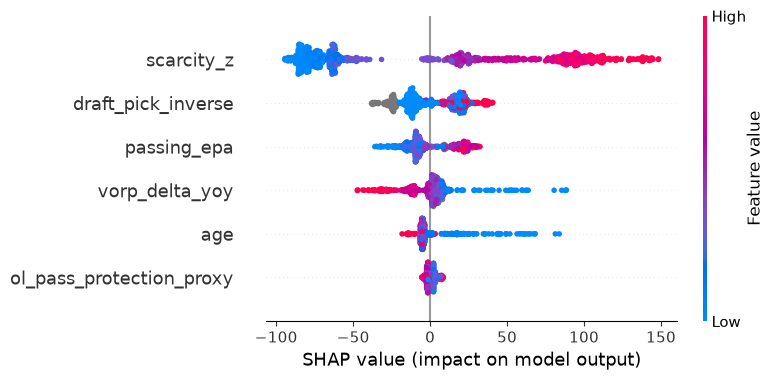

In [2]:
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()

**Figure 1.** SHAP beeswarm plot, all 980 training rows. Each point is one player-season; horizontal position is that row's SHAP contribution to the predicted VORP; color is the underlying feature value (red = high, blue = low).

In [3]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_rank = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_rank["shap_rank"] = shap_rank.index + 1

gain_scores = model.get_booster().get_score(importance_type="gain")
gain_df = pd.DataFrame({"feature": list(gain_scores.keys()), "gain": list(gain_scores.values())})
missing = [f for f in FEATURES if f not in gain_df["feature"].values]
if missing:
    gain_df = pd.concat([gain_df, pd.DataFrame({"feature": missing, "gain": 0.0})], ignore_index=True)
gain_df["gain_share"] = gain_df["gain"] / gain_df["gain"].sum()
gain_df = gain_df.sort_values("gain_share", ascending=False).reset_index(drop=True)
gain_df["gain_rank"] = gain_df.index + 1

comparison = shap_rank.merge(gain_df[["feature", "gain_share", "gain_rank"]], on="feature")
comparison = comparison.sort_values("shap_rank")[["feature", "shap_rank", "mean_abs_shap", "gain_rank", "gain_share"]]
print(comparison.to_string(index=False))

                 feature  shap_rank  mean_abs_shap  gain_rank  gain_share
              scarcity_z          1      71.745590          1    0.623061
      draft_pick_inverse          2      16.562479          3    0.092318
             passing_epa          3      13.296292          2    0.120479
          vorp_delta_yoy          4       8.546336          5    0.053593
                     age          5       8.084600          4    0.071126
ol_pass_protection_proxy          6       2.275791          6    0.039424


**Table 1.** SHAP global ranking (mean absolute SHAP value across all 980 rows) against gain-importance ranking (final shipped model). Both methods agree at the top and bottom: `scarcity_z` is the dominant feature by a wide margin under either measure, and `ol_pass_protection_proxy` is the weakest under either measure.

The two methods disagree in the middle. Gain importance ranks `passing_epa` second and `draft_pick_inverse` third; SHAP ranks them in the opposite order — `draft_pick_inverse` second, `passing_epa` third. Gain importance also ranks `age` fourth and `vorp_delta_yoy` fifth; SHAP reverses that pair too, though by a narrower margin (8.55 against 8.08). Gain importance measures how much a feature reduces training loss when it is used for a split, weighted by how often it is split on; SHAP measures the average magnitude of that feature's contribution to individual predictions, which can diverge when a feature is split on less frequently but produces a larger effect on the rows where it does. The `passing_epa`/`draft_pick_inverse` disagreement is the more material of the two — both features carry double-digit gain share, and the two importance measures rank them oppositely.

## Local explanations: the five QBs from the live 2026 prediction

The same five rows evaluated in `06a_model_qb.ipynb`'s live 2026 prediction section — each QB's real, already-realized 2025 season, feeding a prediction of 2026 VORP. Josh Allen (`|vorp_delta_yoy| = 6.26`) is the unflagged baseline; the other four sit inside or near the extreme-delta region.

=== Trevor Lawrence ===
Predicted 2026 VORP: -40.045   (base -135.861 + sum(SHAP) = -40.045)
                 feature   value       shap
              scarcity_z   2.006 112.346001
          vorp_delta_yoy 214.660 -37.557999
             passing_epa  38.410  18.535999
      draft_pick_inverse   1.000  10.720000
ol_pass_protection_proxy   0.068  -4.239000
                     age  25.906  -3.989000


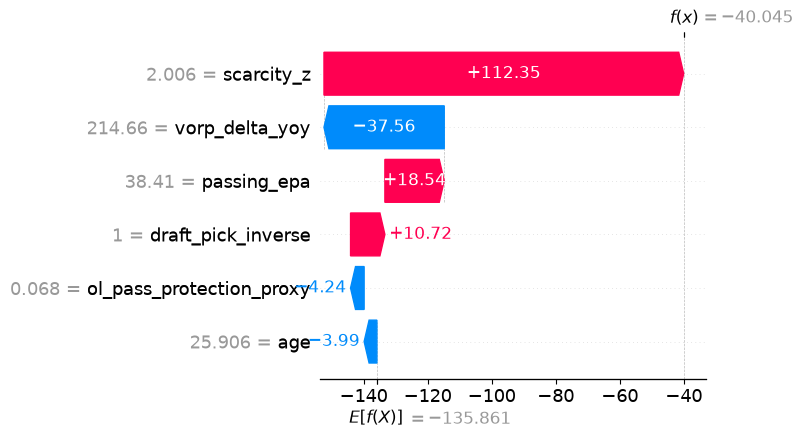


=== Drake Maye ===
Predicted 2026 VORP: 1.517   (base -135.861 + sum(SHAP) = 1.517)
                 feature   value       shap
              scarcity_z   2.085 115.303001
          vorp_delta_yoy 189.000 -35.511002
             passing_epa 166.215  29.704000
      draft_pick_inverse   0.333  16.650999
                     age  23.006  15.272000
ol_pass_protection_proxy   0.087  -4.041000


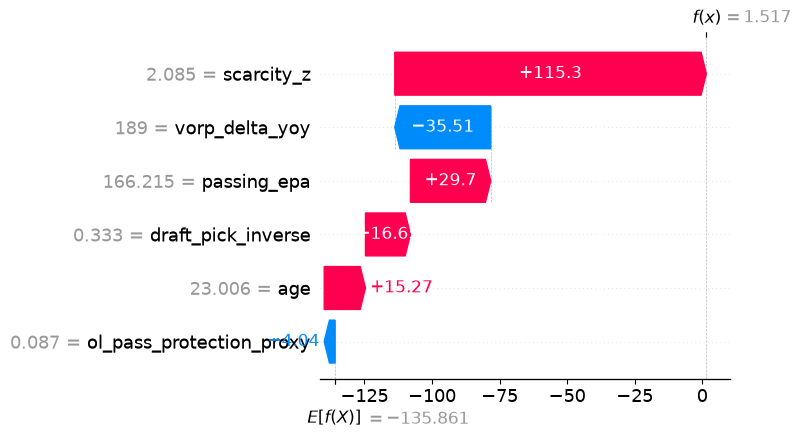


=== Matthew Stafford ===
Predicted 2026 VORP: -37.265   (base -135.861 + sum(SHAP) = -37.265)
                 feature   value       shap
              scarcity_z   2.075 111.941002
          vorp_delta_yoy 152.480 -32.768002
             passing_epa 150.454  19.707001
                     age  37.566 -13.221000
      draft_pick_inverse   1.000  10.374000
ol_pass_protection_proxy   0.037   2.562000


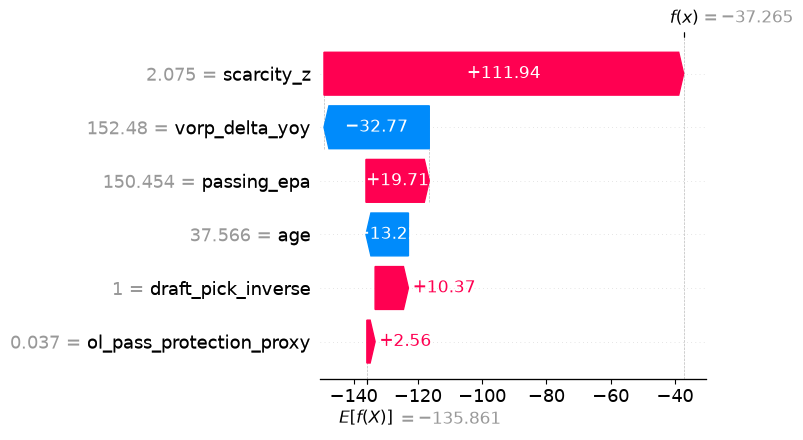


=== Caleb Williams ===
Predicted 2026 VORP: -28.605   (base -135.861 + sum(SHAP) = -28.605)
                 feature  value       shap
              scarcity_z  1.789  84.239998
             passing_epa 42.217  17.485001
          vorp_delta_yoy 80.820 -13.804000
                     age 23.786   9.482000
      draft_pick_inverse  1.000   7.865000
ol_pass_protection_proxy  0.040   1.988000


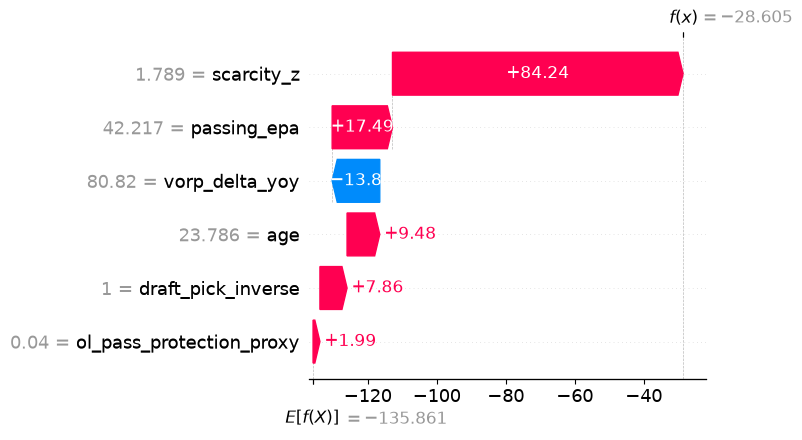


=== Josh Allen ===
Predicted 2026 VORP: 53.463   (base -135.861 + sum(SHAP) = 53.463)
                 feature  value       shap
              scarcity_z  2.213 141.699005
      draft_pick_inverse  0.143  22.917999
             passing_epa 71.326  22.014999
          vorp_delta_yoy  6.260   8.254000
                     age 29.281  -4.092000
ol_pass_protection_proxy  0.075  -1.471000


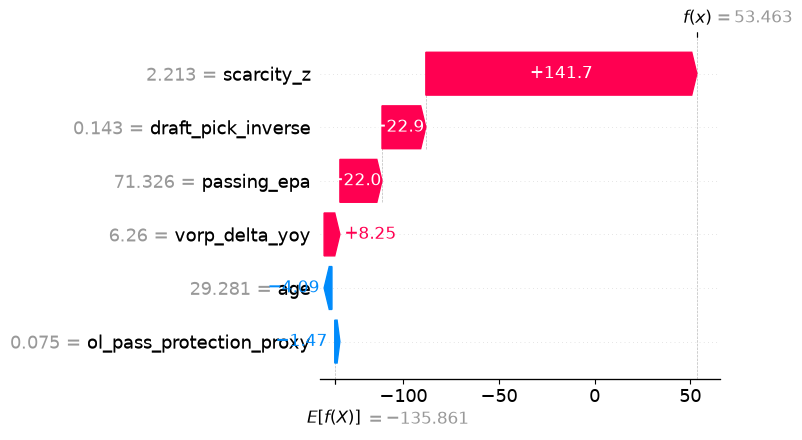

In [4]:
names = ["Trevor Lawrence", "Drake Maye", "Matthew Stafford", "Caleb Williams", "Josh Allen"]
top5_2025 = qb_2025_features.set_index("player_display_name")

local_shap = {}
for name in names:
    row = top5_2025.loc[name, FEATURES]
    sv = explainer(pd.DataFrame([row], columns=FEATURES))
    local_shap[name] = sv
    pred = model.predict(pd.DataFrame([row], columns=FEATURES))[0]

    print(f"=== {name} ===")
    print(f"Predicted 2026 VORP: {pred:.3f}   (base {explainer.expected_value:.3f} + sum(SHAP) = {explainer.expected_value + sv.values[0].sum():.3f})")
    contrib = pd.DataFrame({"feature": FEATURES, "value": row.to_numpy(), "shap": sv.values[0]}).sort_values("shap", key=np.abs, ascending=False)
    print(contrib.round(3).to_string(index=False))
    shap.plots.waterfall(sv[0], show=False)
    plt.tight_layout()
    plt.show()
    print()

**Confirmed against the earlier manual investigation.** The base value shown by every waterfall plot above is `E[f(X)] = -135.861`, matching the previously reported base value of -135.86. Trevor Lawrence's `vorp_delta_yoy` bar reads -37.56, matching the previously reported figure exactly. The formal `shap.TreeExplainer` setup reproduces the earlier ad hoc calculation to the reported precision — this is the expected result for an exact tree explainer applied to the same model and the same input row, not a coincidence, but it is a genuine check rather than an assumed one: nothing about the API guarantees a hand-computed and a library-computed Shapley value must agree to three decimal places if either calculation is wrong.

**Across all five players, `scarcity_z` is the single largest contributor by a wide margin, positive in every case** — each of the five sits in the top scarcity_z decile, and the plots confirm the beeswarm's ranking translates cleanly to the individual level. **`vorp_delta_yoy` is the second-largest contributor for four of the five, and its sign tracks the direction of the swing**: strongly negative for Lawrence (-37.56), Maye (-35.51), and Stafford (-32.77) — each coming off a large positive year-over-year jump — while for Josh Allen, whose delta sits near zero, `vorp_delta_yoy` contributes a negligible +8.25. Caleb Williams is the partial exception: `passing_epa` outranks `vorp_delta_yoy` for him (+17.49 against -13.80), consistent with his delta (80.82) sitting below the other three flagged players' deltas and closer to the boundary of the extreme-tail region.

## Reusable function: `explain_player`

In [5]:
ALL_ROWS = pd.concat([qb, qb_2025_features], ignore_index=True)


def explain_player(player_name, season, top_n=5):
    """Returns the top N features driving qb_model.json's prediction for a given
    player-season, ranked by absolute SHAP contribution, with signed value and direction."""
    match = ALL_ROWS[(ALL_ROWS["player_display_name"] == player_name) & (ALL_ROWS["season"] == season)]
    if match.empty:
        raise ValueError(f"No QB row found for {player_name}, season {season}")
    row = match[FEATURES].iloc[0]
    sv = explainer(pd.DataFrame([row], columns=FEATURES))
    prediction = model.predict(pd.DataFrame([row], columns=FEATURES))[0]

    contrib = pd.DataFrame({
        "feature": FEATURES,
        "feature_value": row.to_numpy(),
        "shap_value": sv.values[0],
    })
    contrib["direction"] = np.where(contrib["shap_value"] >= 0, "increases", "decreases")
    contrib["abs_shap"] = contrib["shap_value"].abs()
    top_5_drivers = contrib.sort_values("abs_shap", ascending=False).head(top_n).drop(columns="abs_shap").reset_index(drop=True)

    print(f"{player_name} ({season} season -> {season + 1} prediction)")
    print(f"Predicted VORP: {prediction:.2f}   Base value: {explainer.expected_value:.2f}")
    print(top_5_drivers.round(3).to_string(index=False))
    return top_5_drivers

In [6]:
_ = explain_player("Kyler Murray", 2021)
print()
_ = explain_player("Dak Prescott", 2021)

Kyler Murray (2021 season -> 2022 prediction)
Predicted VORP: -0.91   Base value: -135.86
           feature  feature_value  shap_value direction
        scarcity_z          1.514   96.402000 increases
       passing_epa         64.441   17.575001 increases
draft_pick_inverse          1.000   13.031000 increases
    vorp_delta_yoy        -68.940    7.919000 increases
               age         24.068    1.253000 increases

Dak Prescott (2021 season -> 2022 prediction)
Predicted VORP: -30.77   Base value: -135.86
                 feature  feature_value  shap_value direction
              scarcity_z          1.672  109.259003 increases
          vorp_delta_yoy        202.740  -32.242001 decreases
             passing_epa        108.333   28.472000 increases
ol_pass_protection_proxy          0.049    6.047000 increases
                     age         28.093   -3.989000 decreases


Both test cases resolve correctly against rows outside the five already covered above. Dak Prescott's 2021 season carries a `vorp_delta_yoy` of 202.74 — inside the extreme-tail region — and `explain_player` surfaces it as the second-largest driver at -32.24, the same pattern seen in Lawrence, Maye, and Stafford above. Kyler Murray's 2021 delta (-68.94) sits outside the extreme-tail region, and its SHAP contribution (+7.92) is correspondingly small relative to `scarcity_z`.

## Mystery 1: the `vorp_delta_yoy` extreme-tail mechanism

`roadmap.md` documents a confirmed, held-out MAE degradation in the `|vorp_delta_yoy| > 100` region across all four modeled positions, with no established mechanism. This section asks what SHAP shows about how the model actually uses this feature as its value grows large, and whether either `age` or `scarcity_z` visibly interacts with that behavior.

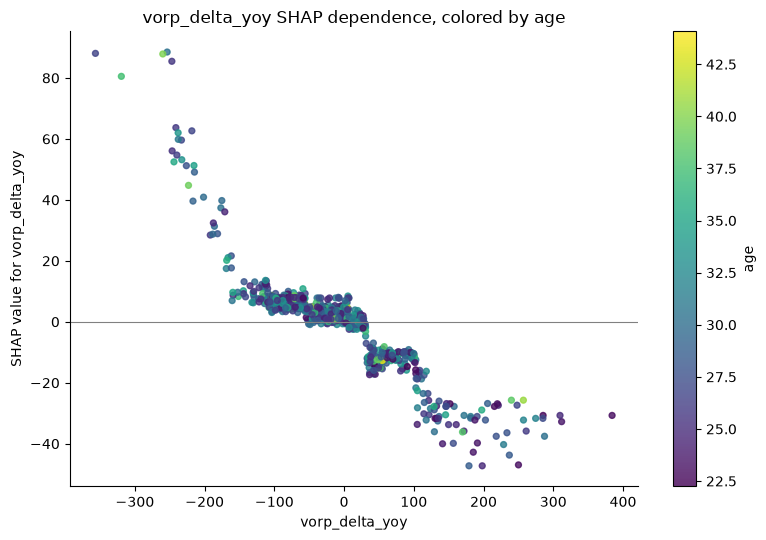

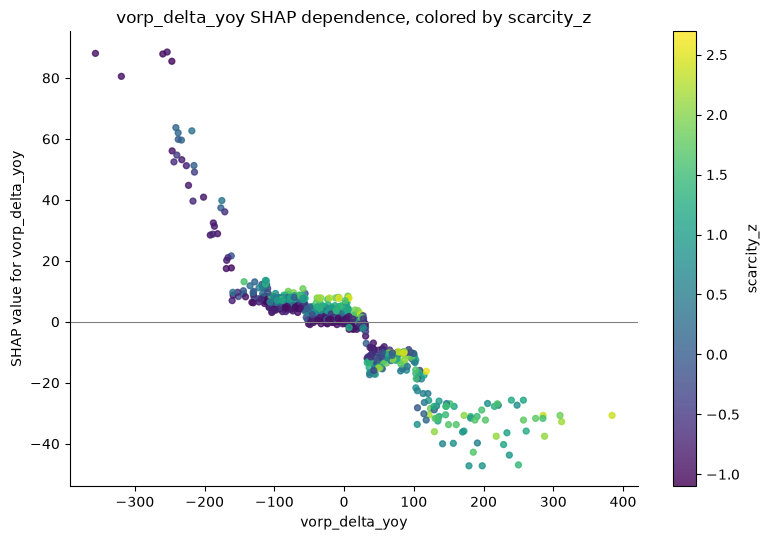

In [7]:
feat_idx = {f: i for i, f in enumerate(FEATURES)}
sv_arr = shap_values.values


def dependence_plot(x_feat, color_feat, title):
    x = qb[x_feat].to_numpy()
    y = sv_arr[:, feat_idx[x_feat]]
    c = qb[color_feat].to_numpy()
    fig, ax = plt.subplots(figsize=(8, 5.5))
    sca = ax.scatter(x, y, c=c, cmap="viridis", s=18, alpha=0.8)
    cb = plt.colorbar(sca, ax=ax)
    cb.set_label(color_feat)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(x_feat)
    ax.set_ylabel(f"SHAP value for {x_feat}")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


dependence_plot("vorp_delta_yoy", "age", "vorp_delta_yoy SHAP dependence, colored by age")
dependence_plot("vorp_delta_yoy", "scarcity_z", "vorp_delta_yoy SHAP dependence, colored by scarcity_z")

In [8]:
d = pd.DataFrame({
    "delta": qb["vorp_delta_yoy"], "shap": sv_arr[:, feat_idx["vorp_delta_yoy"]],
    "age": qb["age"], "scarcity_z": qb["scarcity_z"],
}).dropna()

d["bucket"] = pd.cut(d["delta"], bins=[-1000, -200, -100, -50, 0, 50, 100, 200, 1000])
print("Mean SHAP value by delta bucket:")
print(d.groupby("bucket", observed=True)["shap"].agg(["count", "mean", "std"]).round(2).to_string())

overall_corr = np.corrcoef(d["delta"], d["shap"])[0, 1]
young = d[d["age"] < d["age"].median()]
old = d[d["age"] >= d["age"].median()]
print(f"\nOverall correlation(delta, shap): {overall_corr:.3f}")
print(f"Correlation among younger half (age < {d['age'].median():.1f}): {np.corrcoef(young['delta'], young['shap'])[0, 1]:.3f}")
print(f"Correlation among older half: {np.corrcoef(old['delta'], old['shap'])[0, 1]:.3f}")

Mean SHAP value by delta bucket:
               count       mean    std
bucket                                
(-1000, -200]     20  61.580002  15.99
(-200, -100]      68  12.270000   8.59
(-100, -50]      116   6.070000   1.96
(-50, 0]         190   2.530000   2.09
(0, 50]          178  -3.200000   6.36
(50, 100]         79 -11.470000   1.76
(100, 200]        59 -27.379999   8.67
(200, 1000]       22 -32.669998   5.83

Overall correlation(delta, shap): -0.900
Correlation among younger half (age < 28.5): -0.907
Correlation among older half: -0.892


**Outcome: (a) — a clear, describable mechanism.** The scatter plot is not linear across its full range. Between roughly -100 and +100, the SHAP value falls off steeply and close to linearly with delta. Beyond that range in both directions, the curve visibly flattens: the most negative deltas (below -200) cluster around a SHAP value of +80 to +90 rather than continuing to climb, and the most positive deltas (above +150, extending out to +385) cluster around -30 to -35 rather than continuing to fall. The bucket means confirm the same shape numerically — the step from the (100, 200] bucket to the (200, 1000] bucket (-27.38 to -32.67) is small relative to the step from (50, 100] to (100, 200] (-11.47 to -27.38), even though the second interval spans a far wider range of raw delta values.

This is a saturating, not a linear, relationship, and it is consistent with how a finite gradient-boosted tree ensemble represents a continuous feature: splits partition the feature's range into a finite number of regions, and once a row falls into the most extreme region the tree has a split for, every row beyond that point receives the same leaf contribution regardless of how much further out it sits. A delta of 150 and a delta of 385 are treated as effectively interchangeable by this mechanism, even though their true continuations may differ substantially — which is a direct, mechanistic contributor to the held-out MAE degradation in this region: the model's correction stops scaling with the input once the input is extreme enough, so any true outcome that would have required a still-larger correction is systematically under-corrected.

**No interaction effect with `age`.** Coloring by age shows no visible banding or shift in the curve's shape at any point along the x-axis; the correlation between delta and its SHAP value is nearly identical for the younger half of the sample (-0.907) and the older half (-0.892). Age does not modulate how this feature is used.

**A compositional pattern with `scarcity_z`, not a slope interaction.** Coloring by `scarcity_z` shows the far-negative-delta cluster is populated almost entirely by low (dark purple) `scarcity_z` values, and the far-positive-delta cluster almost entirely by high (green/yellow) values. This reflects real-world correlation between the two features at the extremes — a huge decline coinciding with a huge one-year swing describes a replacement-level player who fell off a big season, and a huge improvement coinciding with a huge swing describes an emerging elite player — rather than a change in the functional relationship itself; the saturating shape of the curve does not visibly differ between the low- and high-`scarcity_z` ends beyond this compositional difference.

## Mystery 2: the `scarcity_z` top-decile difficulty

`roadmap.md` documents a held-out MAE degradation specifically in the top decile of `scarcity_z` at all four positions, alongside an easy bottom decile at a consistent ratio. This section asks whether SHAP shows elevated variance or an interaction effect specifically at the top of `scarcity_z`'s range.

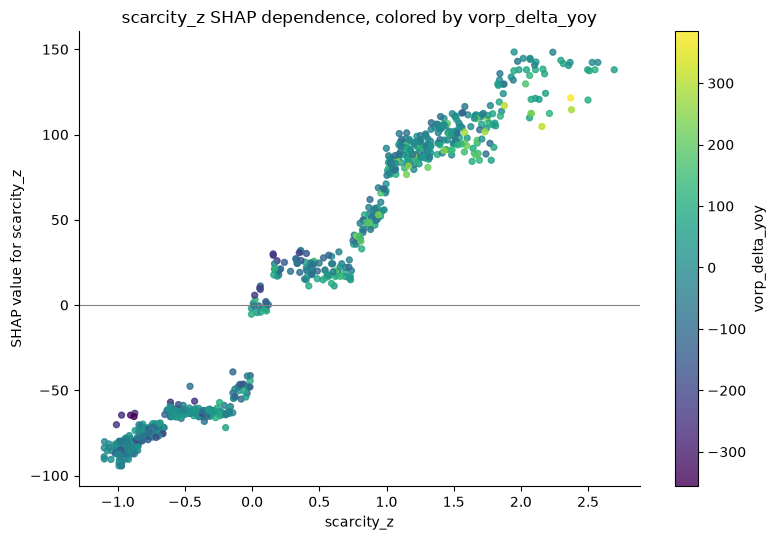

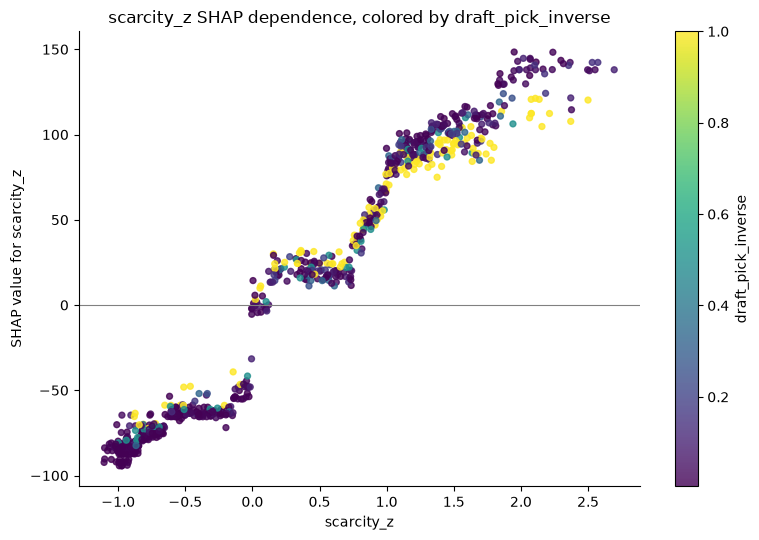

In [9]:
dependence_plot("scarcity_z", "vorp_delta_yoy", "scarcity_z SHAP dependence, colored by vorp_delta_yoy")
dependence_plot("scarcity_z", "draft_pick_inverse", "scarcity_z SHAP dependence, colored by draft_pick_inverse")

In [10]:
s = pd.DataFrame({
    "scarcity_z": qb["scarcity_z"], "shap": sv_arr[:, feat_idx["scarcity_z"]],
    "delta": qb["vorp_delta_yoy"], "draft_pick_inverse": qb["draft_pick_inverse"],
})
s["decile"] = pd.qcut(s["scarcity_z"], 10, labels=False, duplicates="drop")
print("SHAP value by scarcity_z decile:")
print(s.groupby("decile")["shap"].agg(["count", "mean", "std"]).round(2).to_string())

top_decile = s[s["decile"] == s["decile"].max()]
corr_draft = np.corrcoef(top_decile["draft_pick_inverse"].fillna(0), top_decile["shap"])[0, 1]
corr_delta = np.corrcoef(top_decile["delta"].fillna(0), top_decile["shap"])[0, 1]
print(f"\nWithin the top scarcity_z decile (n={len(top_decile)}):")
print(f"  correlation(draft_pick_inverse, shap) = {corr_draft:.3f}")
print(f"  correlation(vorp_delta_yoy, shap) = {corr_delta:.3f}")

SHAP value by scarcity_z decile:
        count        mean        std
decile                              
0          98  -84.230003   4.720000
1          98  -81.820000   4.980000
2          98  -75.169998   3.990000
3          98  -64.970001   6.090000
4          98  -55.509998  14.090000
5          98   16.799999   9.530000
6          98   35.779999  16.209999
7          98   85.730003   9.340000
8          98   98.360001   8.300000
9          98  118.370003  18.010000

Within the top scarcity_z decile (n=98):
  correlation(draft_pick_inverse, shap) = -0.518
  correlation(vorp_delta_yoy, shap) = -0.186


**Outcome: (b) — a suggestive but inconclusive pattern.** The dependence plot itself is a smooth, monotonically increasing curve across the full range of `scarcity_z`, with the same saturating shape seen in Mystery 1 at both ends (flattening below roughly -0.8 and above roughly +2.0) but no visible break, discontinuity, or fan-out specifically at the top decile. The decile table confirms this numerically: the top decile's within-decile standard deviation (18.01) is the highest of the ten deciles, but only marginally above decile 6 (16.21) and decile 4 (14.09) — not a step change that would mark the top decile as qualitatively different from the rest of the distribution.

Coloring by `vorp_delta_yoy` shows no clear banding within the top decile. Coloring by `draft_pick_inverse` shows a real but modest effect: within the top decile, `draft_pick_inverse` correlates negatively with `scarcity_z`'s own SHAP contribution (-0.518) — among the model's most elite QB seasons, a higher-value `draft_pick_inverse` (an earlier draft position) is associated with a smaller `scarcity_z` contribution, holding the actual scarcity value fixed. This is a real, moderate interaction, not a dominant one, and it does not by itself account for a held-out MAE effect of the magnitude reported in `roadmap.md`.

**SHAP dependence describes how the model weighs a feature, not how often its predictions are wrong.** The two are related but distinct: a smooth, well-behaved dependence curve is consistent with the model applying `scarcity_z` the same way at every value, while the held-out top-decile MAE degradation is a statement about how far those consistently-applied predictions land from the true outcome. SHAP does not show an erratic or qualitatively different application of `scarcity_z` at the top decile, which means it does not resolve why that same, consistent function produces larger errors there. The `draft_pick_inverse` interaction is worth carrying into any future feature work on this region, but it is a secondary, modest finding — not the mechanism.

## Summary

The global SHAP ranking confirms `scarcity_z`'s dominance and disagrees with gain importance on the ordering of `passing_epa` and `draft_pick_inverse`, the two features carrying the next-largest share of the model's decision-making. Local explanations for all five previously-investigated QBs, and the base value underlying every one of them, reproduce the earlier manual calculation exactly. `explain_player` generalizes correctly to two rows outside that original set.

Of the two open mechanisms investigated, `vorp_delta_yoy`'s extreme-tail degradation resolves to a clear, describable cause: the feature's SHAP contribution saturates once its magnitude passes roughly ±100-150, a direct consequence of how a finite tree ensemble represents a continuous input, and a direct contributor to the held-out MAE degradation documented at every modeled position. `scarcity_z`'s top-decile difficulty does not resolve the same way — its dependence curve is smooth and consistent across its full range, with only a modest secondary interaction against `draft_pick_inverse` at the extreme end, and no elevated-variance or discontinuous signature that would explain the held-out error pattern already documented. The second mechanism remains open.